# Microbiome State-space EI

This notebook now matches the neural state-space EI design: sample complete microbiome initial states, freely evolve the ecological dynamics, and estimate each node's information about the final whole-system state vector. The paper recovery ranking is used only as a downstream comparison table.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display, Image, Markdown

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'network_revival':
    REPO_ROOT = REPO_ROOT.parents[1]
elif REPO_ROOT.name == 'exp':
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from exp.network_revival.microbiome import MicrobiomeParameters
from exp.network_revival.microbiome_ei import (
    MicrobiomePhiEIDSweepConfig,
    MicrobiomeStateSpaceEIConfig,
    load_microbiome_ei_inputs,
    plot_microbiome_phi_eid_summary,
    plot_microbiome_state_space_ei_comparison,
    run_microbiome_phi_eid_sweep,
    run_microbiome_state_space_node_ei,
)


## Configuration

The editable knobs mirror the neural notebook. `sample_count` controls the number of full-system initial states, and `batch_size` controls how many sampled states are simulated together. With `FORCE_RECOMPUTE=False`, matching cache files are loaded from disk.

In [8]:
FORCE_RECOMPUTE = False
SMOKE = False

if SMOKE:
    microbiome_config = MicrobiomeStateSpaceEIConfig(
        sample_count=128,
        state_low=0.0,
        state_high=0.2,
        tau=0.1,
        dt=0.005,
        seed=42,
        batch_size=64,
        target_noise_fraction=0.01,
        output_dir=REPO_ROOT / 'results/network_revival_microbiome_state_space_ei_smoke',
        params=MicrobiomeParameters(dt=0.005, t_max=0.1),
    )
else:
    microbiome_config = MicrobiomeStateSpaceEIConfig(
        sample_count=100000,
        state_low=0.0,
        state_high=10.0,
        tau=20.0,
        dt=0.05,
        seed=42,
        batch_size=512,
        target_noise_fraction=0.01,
        output_dir=REPO_ROOT / 'results/network_revival_microbiome_state_space_ei',
        params=MicrobiomeParameters(dt=0.05, t_max=20.0),
    )

microbiome_config


MicrobiomeStateSpaceEIConfig(sample_count=100000, state_low=0.0, state_high=10.0, tau=20.0, dt=0.05, seed=42, batch_size=512, target_noise_fraction=0.01, show_progress=True, output_dir=PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_microbiome_state_space_ei'), params=MicrobiomeParameters(positive_weight=30.0, competition_weight=1.0, eco_f=5.0, eco_b=3.0, eco_c=3.0, eco_k=10.0, upper_free_value=10.0, collapsed_free_value=0.1, active_threshold=2.0, delta=10.0, success_threshold=5.0, reach_threshold=1.122, dt=0.05, t_max=20.0, steady_tol=0.001))

## Run or load state-space EI cache

The runner samples `X(0) ~ Uniform[state_low, state_high]^n`, evolves the active microbiome network freely to `tau`, then estimates `I(X_i(0); X(tau))` for every active node.

In [9]:
inputs = load_microbiome_ei_inputs(REPO_ROOT / 'results/network_revival_microbiome')
print('Active adjacency:', inputs['adjacency'].shape)
print('Recovery rows:', len(inputs['recovery_ranked']))

ei_result = run_microbiome_state_space_node_ei(
    microbiome_config,
    adjacency=inputs['adjacency'],
    active_indices=inputs['active_indices'],
    recovery_ranked=inputs['recovery_ranked'],
    force_recompute=False if not FORCE_RECOMPUTE else True,
)

print('Initial states:', ei_result['initial_states'].shape)
print('Final states:', ei_result['final_states'].shape)
print('Summary CSV:', ei_result['cache_paths']['summary_csv'])
print('Comparison CSV:', ei_result['cache_paths']['comparison_csv'])
print('Manifest:', ei_result['cache_paths']['manifest_json'])


Active adjacency: (568, 568)
Recovery rows: 568
Microbiome state-space EI simulation samples 1-100000/100000 (n=568, tau=20.0, batch_size=512)


/Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/dynamics.py:91: RuntimeWarning: overflow encountered in multiply
  return F + B * x * (1 - x / C) * (x - K)
/Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/microbiome_ei.py:177: RuntimeWarning: overflow encountered in multiply
  return model["M0"](x_batch) + model["M1"](x_batch) * interaction
/Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/microbiome_ei.py:177: RuntimeWarning: invalid value encountered in add
  return model["M0"](x_batch) + model["M1"](x_batch) * interaction
/Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/microbiome_ei.py:176: RuntimeWarning: invalid value encountered in matmul
  interaction = model["M2"](x_batch) @ adjacency_op.T
/Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/simulate.py:32: RuntimeWarning: overflow encountered in multiply
  return x + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
/Users/yangmingzhe/Desktop/code/github/EISyn/exp

KeyboardInterrupt: 

## Node ranking and recovery comparison

The EI column is `ei_final_state`, matching the neural state-space notebook. The comparison table aliases that score into the existing recovery metrics so top-k enrichment and success prediction remain directly comparable.

In [ ]:
summary = ei_result['summary'].copy()
comparison = ei_result['comparison'].copy()
metrics = ei_result['metrics']

metric_rows = pd.DataFrame(
    [{'metric': key, 'value': value} for key, value in sorted(metrics.items())]
)
display(metric_rows)

display(summary[['active_node', 'species_index', 'rank_ei_final_state', 'ei_final_state']].head(20))

cols = [
    'active_node', 'species_index', 'species_name', 'ei_rank', 'ei_mean_response',
    'rank', 'tree_size', 'state', 'success', 'ei_residual_vs_tree_size'
]
available_cols = [col for col in cols if col in comparison.columns]
display(comparison.sort_values('ei_rank')[available_cols].head(20))


,metric,value
0,ei_precision_at_10,0.200000
1,ei_precision_at_20,0.100000
2,ei_precision_at_50,0.100000
3,ei_recall_at_10,0.100000
4,ei_recall_at_20,0.100000
5,ei_recall_at_50,0.250000
6,ei_success_auroc,0.584672
7,ei_success_average_precision,0.091159
8,kendall_ei_paper_rank,0.048426
9,kendall_ei_state,0.110620


,active_node,species_index,rank_ei_final_state,ei_final_state
0,422,641,1,2.800149
1,131,174,2,2.535182
2,325,521,3,2.445840
3,335,532,4,2.417802
4,322,518,5,2.417802
5,378,578,6,2.414042
6,460,696,7,2.410488
7,228,328,8,2.406469
8,143,191,9,2.399587
9,405,622,10,2.396033


,active_node,species_index,species_name,ei_rank,ei_mean_response,rank,tree_size,state,success,ei_residual_vs_tree_size
0,422,641,Pseudomonas putida,1,2.800149,20,359,1.180486,False,0.485414
1,131,174,Candidatus Baumannia cicadellinicola,2,2.535182,8,359,9.570853,True,0.220447
2,325,521,Methylocella silvestris,3,2.445840,353,1,0.203406,False,0.170195
3,335,532,Mycobacterium leprae,4,2.417802,363,1,0.203384,False,0.142157
4,322,518,Methylibium petroleiphilum,5,2.417802,350,1,0.203271,False,0.142156
5,378,578,Paenibacillus larvae,6,2.414042,404,1,0.203307,False,0.138396
6,460,696,Staphylococcus aureus,7,2.410488,21,359,11.324182,True,0.095753
7,228,328,Finegoldia magna,8,2.406469,286,1,0.203508,False,0.130824
8,143,191,Citrobacter youngae,9,2.399587,215,1,0.203260,False,0.123942
9,405,622,Prevotella melaninogenica,10,2.396033,425,1,0.203745,False,0.120388


## Figures and interpretation

Figures use state-space labels, so the displayed EI is `I(X_i(0); X(tau))`, not the older single-node ignition score `I(Delta_i; mean final state)`.

ei_ranking_curve /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_microbiome_state_space_ei_smoke/microbiome_state_space_ei_ranking_curve.png


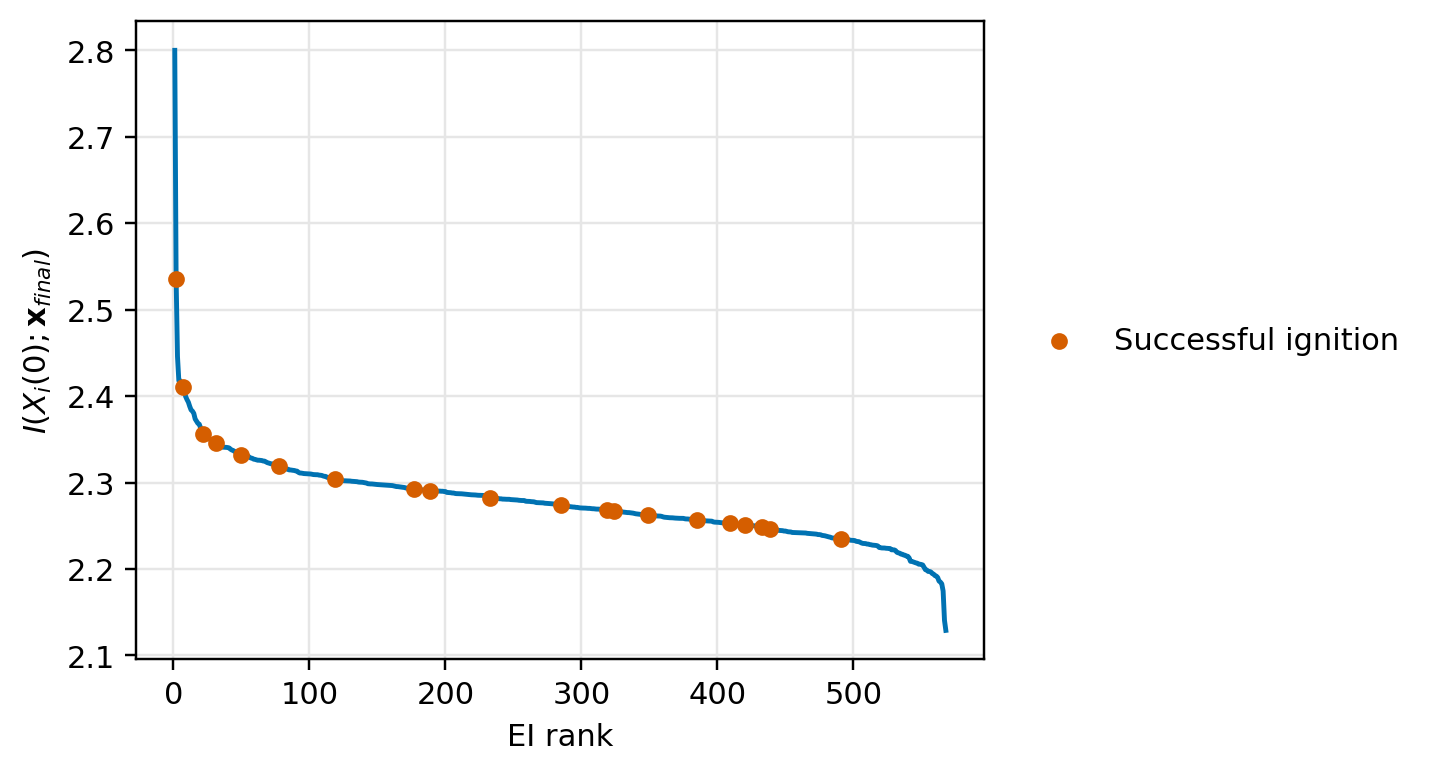

ei_vs_recovery /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_microbiome_state_space_ei_smoke/microbiome_state_space_ei_vs_recovery.png


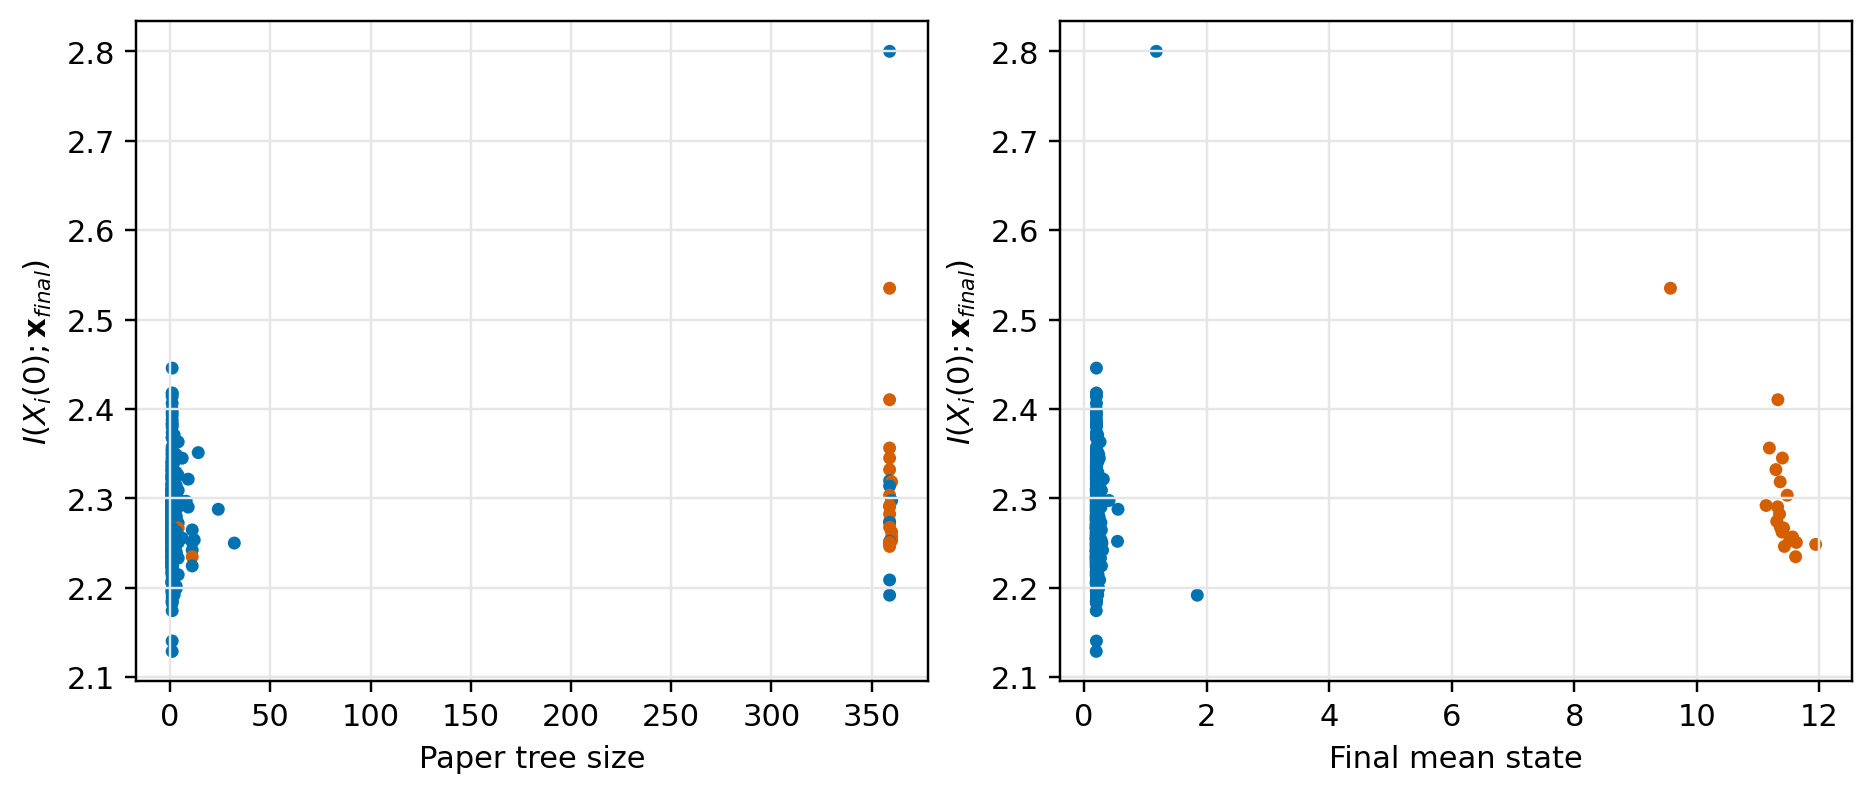

success_enrichment /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_microbiome_state_space_ei_smoke/microbiome_state_space_success_enrichment.png


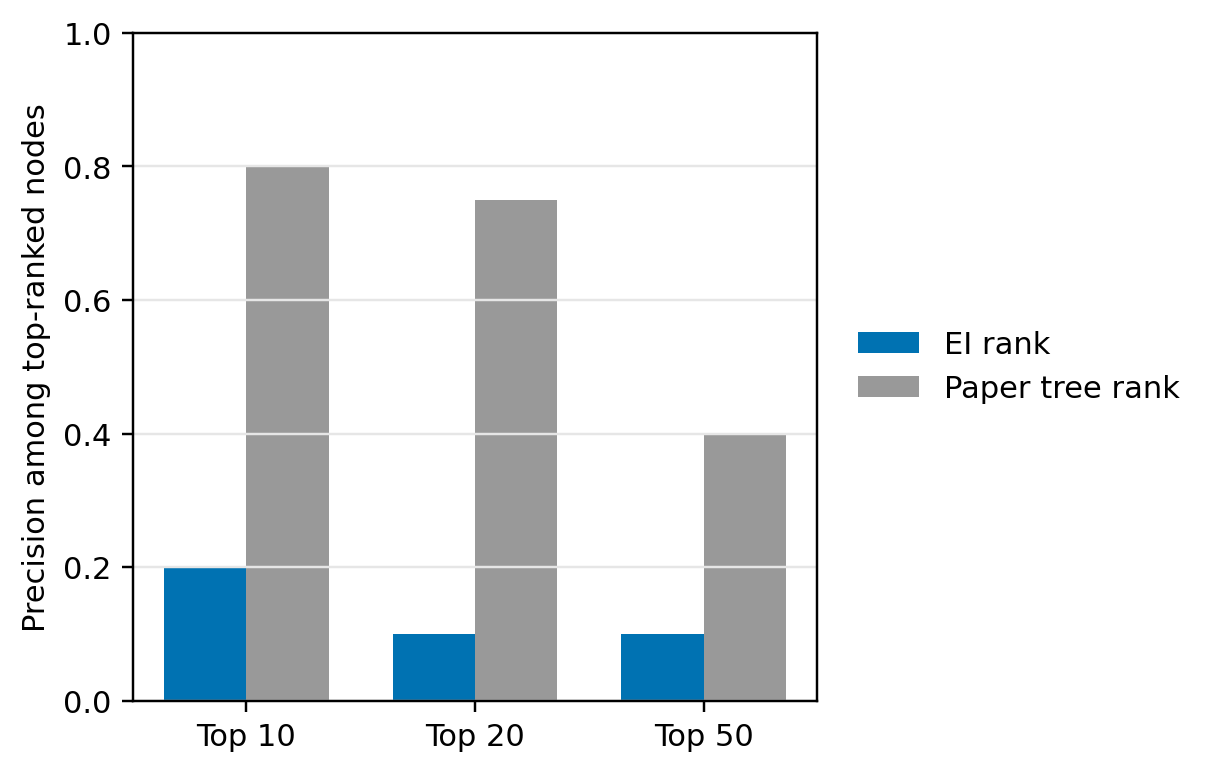

success_prediction /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_microbiome_state_space_ei_smoke/microbiome_state_space_success_prediction_metrics.png


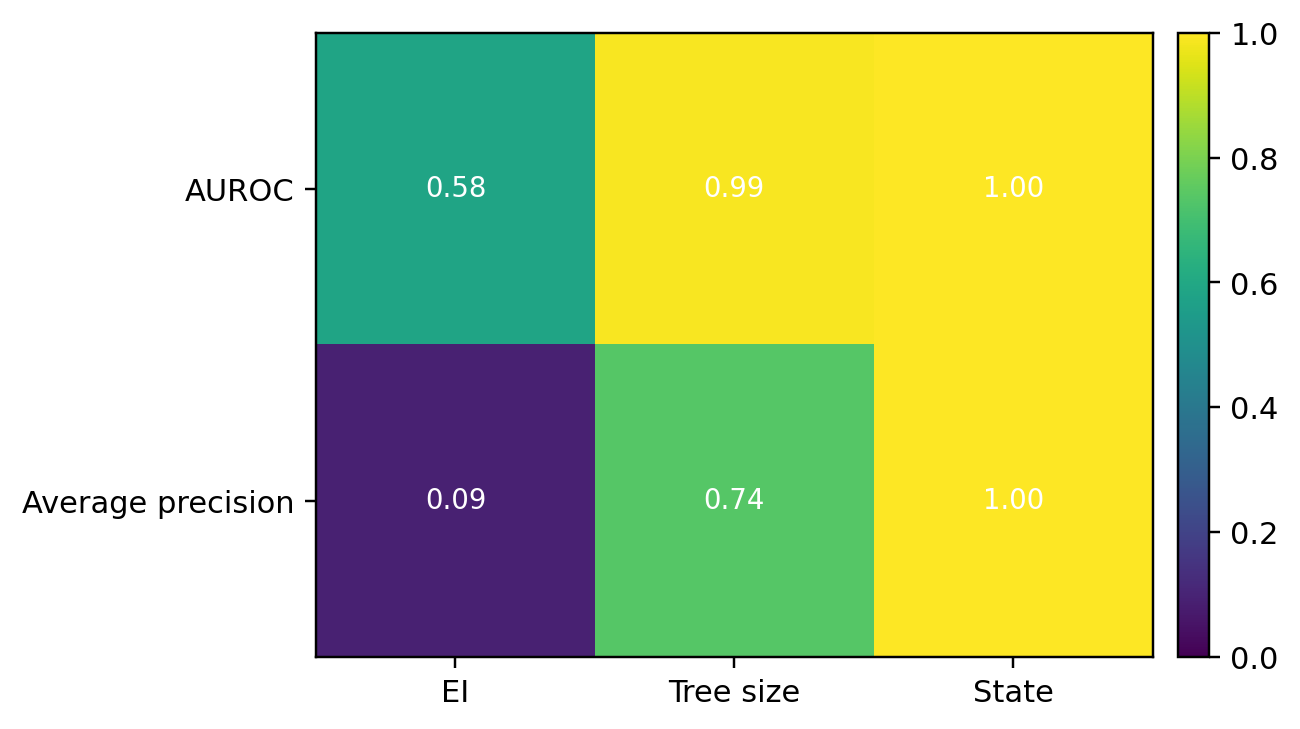

ei_specific_residual /Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_microbiome_state_space_ei_smoke/microbiome_state_space_ei_specific_residual.png


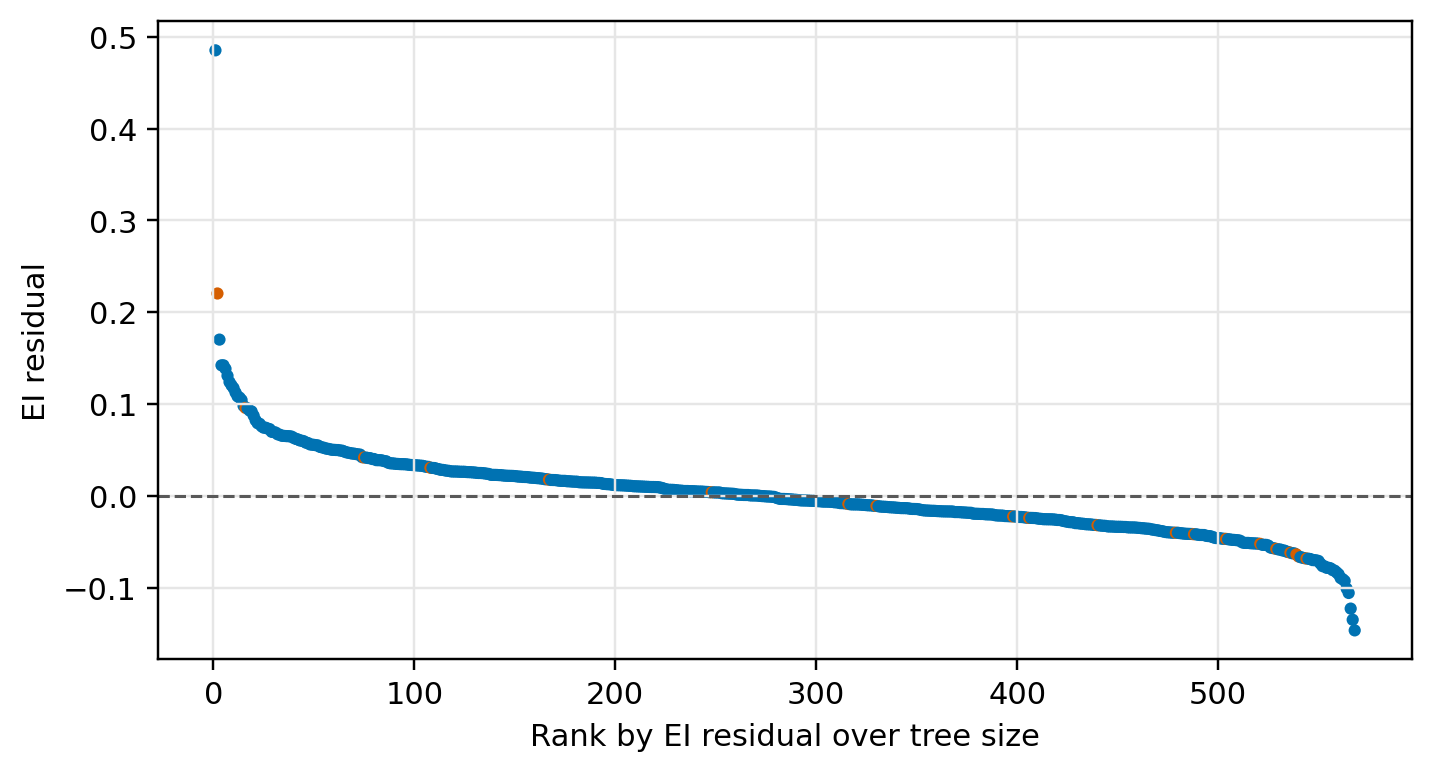


The top state-space EI nodes are **422** (species index 641, EI=2.8) and **131** (species index 174, EI=2.535).
The third node is **325** (species index 521, EI=2.446).
EI-success AUROC is **0.585**, compared with tree-size AUROC **0.990** and final-state AUROC **1.000**.


In [5]:
figure_paths = plot_microbiome_state_space_ei_comparison(
    comparison,
    metrics,
    microbiome_config.output_dir,
    k_values=(10, 20, 50),
)

for name, figure_path in figure_paths.items():
    print(name, figure_path)
    display(Image(filename=str(figure_path)))

top = summary.sort_values('rank_ei_final_state').head(3).reset_index(drop=True)
first, second, third = top.iloc[0], top.iloc[1], top.iloc[2]
display(Markdown(f'''
The top state-space EI nodes are **{int(first.active_node)}** (species index {int(first.species_index)}, EI={first.ei_final_state:.4g}) and **{int(second.active_node)}** (species index {int(second.species_index)}, EI={second.ei_final_state:.4g}).
The third node is **{int(third.active_node)}** (species index {int(third.species_index)}, EI={third.ei_final_state:.4g}).
EI-success AUROC is **{metrics.get('ei_success_auroc', float('nan')):.3f}**, compared with tree-size AUROC **{metrics.get('tree_size_success_auroc', float('nan')):.3f}** and final-state AUROC **{metrics.get('state_success_auroc', float('nan')):.3f}**.
'''))


## Phi^EID parameter sweep

This cache-first sweep estimates whole-system $\Phi^{EID}=I(X(0);X(\tau))-\sum_i I(X_i(0);X(\tau))$ over `sample_count` and `tau`. The goal is parameter selection: find conditions where whole-system synergy is large and nonnegative.

In [6]:
phi_sweep_config = MicrobiomePhiEIDSweepConfig(
    sample_counts=(5000, 10000, 20000, 50000),
    tau_values=(0.1, 1.0, 5.0, 10.0, 20.0, 40.0),
    state_low=0.0,
    state_high=10.0,
    dt=0.05,
    seed=42,
    batch_size=512,
    target_noise_fraction=0.01,
    output_dir=REPO_ROOT / 'results/network_revival_microbiome_phi_eid_sweep',
    params=MicrobiomeParameters(dt=0.05, t_max=20.0),
)

phi_sweep_config


MicrobiomePhiEIDSweepConfig(sample_counts=(5000, 10000, 20000, 50000), tau_values=(0.1, 1.0, 5.0, 10.0, 20.0, 40.0), state_low=0.0, state_high=10.0, dt=0.05, seed=42, batch_size=512, target_noise_fraction=0.01, show_progress=True, output_dir=PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_microbiome_phi_eid_sweep'), params=MicrobiomeParameters(positive_weight=30.0, competition_weight=1.0, eco_f=5.0, eco_b=3.0, eco_c=3.0, eco_k=10.0, upper_free_value=10.0, collapsed_free_value=0.1, active_threshold=2.0, delta=10.0, success_threshold=5.0, reach_threshold=1.122, dt=0.05, t_max=20.0, steady_tol=0.001))

In [7]:
phi_result = run_microbiome_phi_eid_sweep(
    phi_sweep_config,
    adjacency=inputs['adjacency'],
    active_indices=inputs['active_indices'],
    force_recompute=False if not FORCE_RECOMPUTE else True,
)

phi_grid = phi_result['grid']
phi_top_conditions = phi_result['top_conditions']

display(phi_top_conditions.head(10))
print('Grid CSV:', phi_result['cache_paths']['grid_csv'])
print('Top conditions CSV:', phi_result['cache_paths']['top_conditions_csv'])
print('Manifest:', phi_result['cache_paths']['manifest_json'])


Microbiome Phi^EID sweep 1/24: sample_count=5000, tau=0.1


/Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/dynamics.py:91: RuntimeWarning: overflow encountered in multiply
  return F + B * x * (1 - x / C) * (x - K)
/Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/microbiome_ei.py:177: RuntimeWarning: overflow encountered in multiply
  return model["M0"](x_batch) + model["M1"](x_batch) * interaction
/Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/microbiome_ei.py:177: RuntimeWarning: invalid value encountered in add
  return model["M0"](x_batch) + model["M1"](x_batch) * interaction
/Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/microbiome_ei.py:176: RuntimeWarning: invalid value encountered in matmul
  interaction = model["M2"](x_batch) @ adjacency_op.T
/Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/simulate.py:32: RuntimeWarning: overflow encountered in multiply
  return x + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


Microbiome Phi^EID sweep 2/24: sample_count=5000, tau=1


/Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/microbiome_ei.py:176: RuntimeWarning: overflow encountered in matmul
  interaction = model["M2"](x_batch) @ adjacency_op.T
/Users/yangmingzhe/Desktop/code/github/EISyn/exp/network_revival/simulate.py:32: RuntimeWarning: invalid value encountered in add
  return x + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


Microbiome Phi^EID sweep 3/24: sample_count=5000, tau=5
Microbiome Phi^EID sweep 4/24: sample_count=5000, tau=10
Microbiome Phi^EID sweep 5/24: sample_count=5000, tau=20
Microbiome Phi^EID sweep 6/24: sample_count=5000, tau=40


KeyboardInterrupt: 

In [ ]:
phi_figure_paths = plot_microbiome_phi_eid_summary(phi_grid, phi_sweep_config.output_dir)
for name, figure_path in phi_figure_paths.items():
    print(name, figure_path)
    display(Image(filename=str(figure_path)))

best = phi_top_conditions.iloc[0]
display(Markdown(f'''
The largest whole-system $\\Phi^{{EID}}$ occurs at **sample_count={int(best.sample_count)}** and **tau={best.tau:g}**, with $\\Phi^{{EID}}={best.phi_eid:.4g}$ and $\\Phi^{{EID}}/EI={best.phi_ratio:.3f}$.
This condition is the preferred setting for follow-up microbiome whole-system synergy analysis.
'''))
